# GEO-Equidade
## Metodologia aberta de auditoria territorial em dados geoespaciais

**Estudo-piloto: Porto Alegre, Rio Grande do Sul, Brasil**

GEO-Equidade é uma metodologia exploratória para examinar a disponibilidade relativa de serviços mapeados em bases geoespaciais abertas. O objetivo é sinalizar territórios que demandam validação, atualização ou integração de dados antes que essas bases sejam usadas em aplicações de priorização, alerta, roteamento ou resposta a riscos.

A versão-piloto analisa 12 bairros de Porto Alegre por meio da **Razão Serviços/Nó**, calculada pela relação entre feições classificadas como serviços e nós topológicos da rede de vias no OpenStreetMap.

**Artigo de referência:** *Quem não está no mapa, não está no algoritmo: sub-representação em dados geoespaciais abertos e implicações para sistemas de resposta a risco em Porto Alegre.*

> **Importante:** a Razão Serviços/Nó não mede a oferta real de serviços, não estima a completude absoluta do mapa e não prova causalidade. Ela descreve diferenças relativas na cobertura de feições mapeadas e apoia auditorias territoriais.

**Dados utilizados**
- OpenStreetMap e extrato Geofabrik: rede de vias e feições classificadas como serviços.
- IBGE/SIDRA: população utilizada na seleção do recorte.
- Malha geométrica dos municípios brasileiros (IBGE, catalogada no Portal Brasileiro de Dados Abertos): delimitação e conferência do recorte municipal.

**Tecnologias:** Python, GeoPandas, pyrosm, OSMnx, NetworkX, Pandas.

**Licenças e atribuição:** os dados do OpenStreetMap são disponibilizados sob a Open Database License (ODbL). Este notebook preserva a atribuição ao OpenStreetMap e às demais fontes utilizadas.


## 1. Ambiente e dependências

Esta seção importa as bibliotecas necessárias para consultar, processar e analisar dados geoespaciais abertos. As versões das bibliotecas e a data do processamento devem ser registradas para reprodução dos resultados.


In [ ]:
%pip install ipykernel osmnx geopandas pandas matplotlib requests folium pyrosm

> Recomenda-se executar o notebook em ambiente isolado e registrar as versões instaladas. O processamento de extratos PBF pode exigir memória e espaço em disco compatíveis com o tamanho do arquivo utilizado.


In [ ]:
import time
import random
import requests
import osmnx as ox
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Ajustes de rede: cache liga para não reconsultar o que já foi resolvido,
# timeout generoso, e rate limit respeitado (evita o "Connection refused" recorrente por excesso de chamadas em sequência).
ox.settings.log_console = False
ox.settings.use_cache = True
ox.settings.timeout = 180
ox.settings.overpass_rate_limit = True

## 2. Dados populacionais e composição do recorte

São obtidos dados populacionais por bairro de Porto Alegre a partir do IBGE/SIDRA. Esses dados são utilizados exclusivamente para compor a amostra de bairros; não entram diretamente no cálculo da Razão Serviços/Nó.


In [3]:
url_ibge_pop = "https://servicodados.ibge.gov.br/api/v3/agregados/9923/variaveis/93?localidades=N102[N6[4314902]]"

response = requests.get(url_ibge_pop)
response.raise_for_status()
dados_json = response.json()

lista_bairros = []
series = dados_json[0]['resultados'][0]['series']

for serie in series:
    nome_bairro = serie['localidade']['nome'].split(' - ')[0]
    val_pop = list(serie['serie'].values())[0]
    populacao = int(val_pop) if val_pop not in ['-', 'X', '..'] else 0
    lista_bairros.append({'Bairro': nome_bairro, 'População': populacao})

df_base = pd.DataFrame(lista_bairros)
print(f"Base populacional carregada: {len(df_base)} bairros mapeados.")
display(df_base.head())

Base populacional carregada: 94 bairros mapeados.


,Bairro,População
0,Medianeira,8749
1,Praia de Belas,1522
2,Cidade Baixa,13014
3,Menino-Deus,27961
4,Farroupilha,774


## 3. Geometrias de bairros, área e densidade demográfica

Os limites de bairros são consultados via Nominatim/OpenStreetMap e reprojetados para SIRGAS 2000 / UTM zona 22S (EPSG:31982), permitindo cálculo de área em quilômetros quadrados e densidade demográfica.

As falhas de geocodificação são registradas e reportadas. Nenhum valor é estimado ou preenchido quando a geometria não pode ser obtida.

> Limitação: os polígonos retornados pelo Nominatim não substituem necessariamente limites administrativos oficiais e devem ser interpretados como geometrias disponíveis na data da consulta.


In [4]:
dados_processados = []
falhas_densidade = []

for _, row in df_base.iterrows():
    bairro, pop = row['Bairro'], row['População']
    if pop == 0:
        continue

    try:
        gdf_bairro = ox.geocode_to_gdf(f"{bairro}, Porto Alegre, Rio Grande do Sul, Brasil")
        area_km2 = gdf_bairro.to_crs(epsg=31982).geometry.area.iloc[0] / 10**6
        densidade = pop / area_km2 if area_km2 > 0 else 0

        dados_processados.append({
            'Bairro': bairro, 'População': pop,
            'Área (km²)': round(area_km2, 2),
            'Densidade (hab/km²)': round(densidade, 1)
        })
    except Exception as e:
        falhas_densidade.append((bairro, str(e)))

df_densidade = pd.DataFrame(dados_processados).sort_values(
    by='Densidade (hab/km²)', ascending=False
).reset_index(drop=True)

print(f"Densidade calculada para {len(df_densidade)}/{len(df_base[df_base['População']>0])} bairros com população > 0.")
if falhas_densidade:
    print(f"\n{len(falhas_densidade)} bairro(s) NÃO entraram no ranking de densidade por falha de geocodificação:")
    for b, err in falhas_densidade:
        print(f"  - {b}: {err}")
display(df_densidade.head(10))

Densidade calculada para 94/94 bairros com população > 0.


,Bairro,População,Área (km²),Densidade (hab/km²)
0,Bom Fim,10160,0.49,20775.1
1,Cidade Baixa,13014,0.76,17082.3
2,Independência,6885,0.44,15555.6
3,Mont'Serrat,10357,0.79,13058.7
4,Centro Histórico,30569,2.42,12625.2
5,Jardim Leopoldina,16151,1.29,12474.0
6,Menino-Deus,27961,2.30,12161.6
7,Rio Branco,15710,1.34,11718.8
8,Bom Jesus,24589,2.10,11702.6
9,Santana,17794,1.53,11601.9


## 4. Seleção de bairros candidatos

O recorte inicial é formado pela união entre os 10 bairros de maior população e os 10 de maior densidade demográfica. A seleção é intencional e exploratória: seu objetivo é construir um conjunto comparável de bairros com presença relevante de população ou densidade, não representar estatisticamente todos os bairros de Porto Alegre.


In [5]:
top_pop_bairros = df_base.sort_values(by='População', ascending=False).head(10)[['Bairro', 'População']].copy()
top_dens_bairros = df_densidade.head(10)[['Bairro', 'População', 'Área (km²)', 'Densidade (hab/km²)']].copy()

df_amostra_multicriterio = pd.concat([top_pop_bairros, top_dens_bairros]).drop_duplicates(
    subset=['Bairro']
).reset_index(drop=True)

df_amostra_multicriterio['Critério Principal'] = df_amostra_multicriterio['Bairro'].apply(
    lambda b: 'População' if b in top_pop_bairros['Bairro'].values else 'Densidade'
)

# Preenche Área/Densidade ausentes (bairros que só entraram pelo ranking populacional)
for idx, row in df_amostra_multicriterio.iterrows():
    if pd.isna(row['Área (km²)']) or pd.isna(row['Densidade (hab/km²)']):
        bairro, pop = row['Bairro'], row['População']
        try:
            gdf_bairro = ox.geocode_to_gdf(f"{bairro}, Porto Alegre, Rio Grande do Sul, Brasil")
            area_km2 = gdf_bairro.to_crs(epsg=31982).geometry.area.iloc[0] / 10**6
            densidade = pop / area_km2 if area_km2 > 0 else 0
            df_amostra_multicriterio.loc[idx, 'Área (km²)'] = round(area_km2, 2)
            df_amostra_multicriterio.loc[idx, 'Densidade (hab/km²)'] = round(densidade, 1)
        except Exception as e:
            print(f"  -> Aviso: não foi possível calcular área de {bairro}: {e}")

print(f"Total de candidatos únicos (Top 10 população ∪ Top 10 densidade): N = {len(df_amostra_multicriterio)}")
display(df_amostra_multicriterio)

Total de candidatos únicos (Top 10 população ∪ Top 10 densidade): N = 19


,Bairro,População,Área (km²),Densidade (hab/km²),Critério Principal
0,Restinga,62448,20.09,3108.4,População
1,Lomba do Pinheiro,59200,31.16,1900.0,População
2,Sarandi,51539,8.99,5734.2,População
3,Mário Quintana,44068,7.52,5861.6,População
4,Partenon,43587,6.33,6887.8,População
5,Petrópolis,37613,3.36,11180.4,População
6,Santa Rosa de Lima,34627,5.47,6333.6,População
7,Vila Nova,32217,12.05,2674.3,População
8,Santa Tereza,31358,4.51,6946.2,População
9,Centro Histórico,30569,2.42,12625.2,População


## 5. Macrozona analítica e amostra final

Os bairros candidatos são agrupados em quatro macrozonas analíticas — Centro, Zona Norte, Zona Sul e Zona Leste — para fins de comparação territorial. Essa classificação é uma escolha analítica do estudo e não substitui regionalizações administrativas oficiais de Porto Alegre.

Em cada macrozona, são selecionados os três bairros de maior população entre os candidatos. A amostra final contém 12 bairros.

> Limitação: a classificação por macrozona simplifica heterogeneidades internas e não deve ser interpretada como uma definição única de periferia, centralidade ou vulnerabilidade.


In [6]:
# Classificação analítica adotada para comparação territorial.
# Não representa regionalização administrativa oficial do município.
MACROZONAS = {
    "Centro Histórico": "Centro",
    "Bom Fim": "Centro",
    "Cidade Baixa": "Centro",
    "Independência": "Centro",
    "Mont'Serrat": "Centro",
    "Santana": "Centro",
    "Sarandi": "Zona Norte",
    "Mário Quintana": "Zona Norte",
    "Jardim Leopoldina": "Zona Norte",
    "Restinga": "Zona Sul",
    "Vila Nova": "Zona Sul",
    "Santa Tereza": "Zona Sul",
    "Santa Rosa de Lima": "Zona Sul",
    "Partenon": "Zona Leste",
    "Lomba do Pinheiro": "Zona Leste",
    "Petrópolis": "Zona Leste",
    "Bom Jesus": "Zona Leste",
    "Rio Branco": "Centro",
    "Menino-Deus": "Centro",
}

# Parâmetros da seleção — ajuste aqui, não espalhado pelo notebook.
ZONAS_INCLUIDAS = ["Centro", "Zona Norte", "Zona Sul", "Zona Leste"]  # FIX: Zona Leste incluída — necessária para reproduzir os 12 bairros do artigo
N_POR_ZONA = 3
CRITERIO_DESEMPATE = "População"  # coluna usada para ordenar dentro de cada zona

df_amostra_multicriterio["Macrozona"] = df_amostra_multicriterio["Bairro"].map(MACROZONAS)

nao_classificados = df_amostra_multicriterio[df_amostra_multicriterio["Macrozona"].isna()]
if not nao_classificados.empty:
    print("Bairros SEM macrozona no dicionário (excluídos da seleção, não silenciosamente):")
    for b in nao_classificados["Bairro"]:
        print(f"  - {b} — adicione ao dicionário MACROZONAS se quiser incluí-lo")
    print()

df_zonas_incluidas = df_amostra_multicriterio[
    df_amostra_multicriterio["Macrozona"].isin(ZONAS_INCLUIDAS)
].copy()

excluidos_por_zona = df_amostra_multicriterio[
    df_amostra_multicriterio["Macrozona"].notna() &
    ~df_amostra_multicriterio["Macrozona"].isin(ZONAS_INCLUIDAS)
]
if not excluidos_por_zona.empty:
    print(f"Bairros classificados mas fora de ZONAS_INCLUIDAS={ZONAS_INCLUIDAS} (excluídos por decisão de escopo, não por falha):")
    for _, r in excluidos_por_zona.iterrows():
        print(f"  - {r['Bairro']} ({r['Macrozona']})")
    print("  -> Declare essa exclusão de escopo explicitamente na seção de Metodologia do artigo.\n")

df_selecao_final = (
    df_zonas_incluidas
    .sort_values(CRITERIO_DESEMPATE, ascending=False)
    .groupby("Macrozona", group_keys=False)
    .head(N_POR_ZONA)
    .reset_index(drop=True)
)

print(f"Amostra final selecionada: N = {len(df_selecao_final)} "
      f"({N_POR_ZONA} por zona x {len(ZONAS_INCLUIDAS)} zonas)")
display(df_selecao_final[["Bairro", "Macrozona", "População", "Área (km²)",
                           "Densidade (hab/km²)", "Critério Principal"]])

BAIRROS = df_selecao_final["Bairro"].tolist()

Amostra final selecionada: N = 12 (3 por zona x 4 zonas)


,Bairro,Macrozona,População,Área (km²),Densidade (hab/km²),Critério Principal
0,Restinga,Zona Sul,62448,20.09,3108.4,População
1,Lomba do Pinheiro,Zona Leste,59200,31.16,1900.0,População
2,Sarandi,Zona Norte,51539,8.99,5734.2,População
3,Mário Quintana,Zona Norte,44068,7.52,5861.6,População
4,Partenon,Zona Leste,43587,6.33,6887.8,População
5,Petrópolis,Zona Leste,37613,3.36,11180.4,População
6,Santa Rosa de Lima,Zona Sul,34627,5.47,6333.6,População
7,Vila Nova,Zona Sul,32217,12.05,2674.3,População
8,Centro Histórico,Centro,30569,2.42,12625.2,População
9,Menino-Deus,Centro,27961,2.30,12161.6,Densidade


## 6. Delimitação municipal com dado aberto catalogado

A **Malha geométrica dos municípios brasileiros**, disponibilizada pelo IBGE no Portal Brasileiro de Dados Abertos, é utilizada para delimitar e conferir o recorte municipal de Porto Alegre, código IBGE 4314902.

Nesta versão, foi utilizado o recurso "Malha geométrica dos municípios do Rio Grande do Sul (RS) em 2010", disponibilizado em formato ZIP + SHP. A malha municipal é empregada exclusivamente para conferência do recorte espacial. Ela não define os limites dos bairros, não entra no cálculo da Razão Serviços/Nó e não é utilizada como base atualizada de estrutura intraurbana.

**Conjunto catalogado:** https://dados.gov.br/dados/conjuntos-dados/malha-geometrica-dos-municipios-brasileiros

> **NÃO TESTADO** — esta célula não foi executada. Confirme a URL exata do recurso RS e o nome da coluna de geocódigo antes de considerar esta seção validada.


['ID', 'CD_GEOCODM', 'NM_MUNICIP', 'geometry']


Text(0.5, 1.0, 'Conferência: recorte municipal IBGE (dados.gov.br) — Porto Alegre')

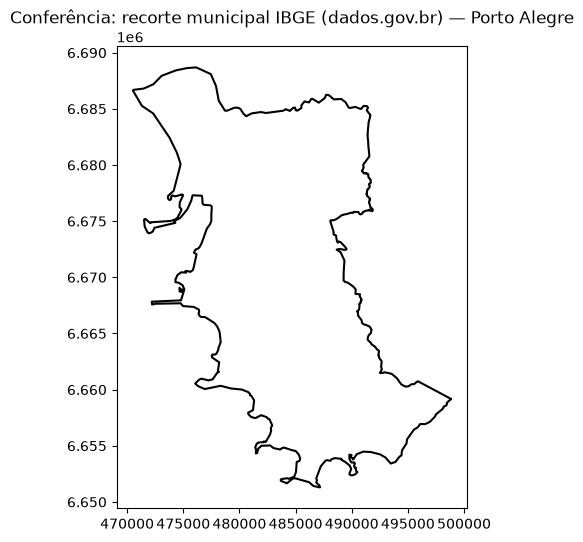

In [9]:
import geopandas as gpd
import requests, zipfile, io

url_malha_rs = "https://geoftp.ibge.gov.br/organizacao_do_territorio/malhas_territoriais/malhas_municipais/municipio_2010/rs/rs_municipios.zip"

resp = requests.get(url_malha_rs, timeout=60)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    z.extractall("malha_rs_2010")

gdf_municipios_rs = gpd.read_file("malha_rs_2010")

# O nome da coluna de código do município varia entre versões do shapefile do IBGE
# (ex.: 'CD_GEOCMU', 'GEOCODIGO', 'CD_MUN').
print(gdf_municipios_rs.columns.tolist())

CODIGO_POA = "4314902"
col_geocodigo = "CD_GEOCODM"

gdf_poa = gdf_municipios_rs[gdf_municipios_rs[col_geocodigo] == CODIGO_POA]
assert not gdf_poa.empty, "Porto Alegre (4314902) não encontrado — confira o nome da coluna."

gdf_poa = gdf_poa.to_crs(epsg=31982)

ax = gdf_poa.boundary.plot(figsize=(6, 6), color="black")
df_selecao_final_geom = df_selecao_final.copy()  # apenas para referência; plot de conferência é qualitativo
ax.set_title("Conferência: recorte municipal IBGE (dados.gov.br) — Porto Alegre")


## 7. Dados do OpenStreetMap e extrato Geofabrik

As feições do OpenStreetMap são processadas a partir de arquivo PBF disponibilizado pela Geofabrik e recortado localmente para Porto Alegre. O uso de extrato local reduz dependência de consultas repetidas a serviços públicos de API e torna o processamento mais reproduzível.

O arquivo PBF utilizado deve ter sua URL de origem, data de download, tamanho e checksum registrados nesta seção.


In [10]:
import requests

GEOFABRIK_URL = "https://download.geofabrik.de/south-america/brazil-latest.osm.pbf"
CAMINHO_PBF = "brazil-latest.osm.pbf"

# Download único (aprox. 2GB) — roda uma vez só, nas execuções seguintes ela pula o download se o arquivo já existir em disco.
import os

if not os.path.exists(CAMINHO_PBF):
    print("Baixando extrato do Brasil (Geofabrik) — isso é feito uma única vez...")
    with requests.get(GEOFABRIK_URL, stream=True, timeout=600) as r:
        r.raise_for_status()
        total = int(r.headers.get('content-length', 0))
        baixado = 0
        with open(CAMINHO_PBF, 'wb') as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                f.write(chunk)
                baixado += len(chunk)
                if total:
                    print(f"\r  {baixado/total:.1%} ({baixado/1e6:.0f}MB/{total/1e6:.0f}MB)", end="")
    print("\nDownload concluído.")
else:
    print(f"Arquivo {CAMINHO_PBF} já existe em disco — pulando download.")

Baixando extrato do Brasil (Geofabrik) — isso é feito uma única vez...
  100.0% (2082MB/2082MB)
Download concluído.


## 8. Categorias analíticas de feições

**Serviços** (única categoria que compõe o numerador da Razão Serviços/Nó): `amenity=*`, `shop=*`, `healthcare=*`, `office=*`, `tourism=*` e `leisure=*`.

A categoria "serviços" reúne, para fins analíticos, equipamentos, estabelecimentos e lugares de interesse urbano sob as tags selecionadas. Ela não equivale ao universo de serviços existentes no território.

> **Correção em relação a versões anteriores deste notebook:** o filtro anterior (`TAGS_ALVO`) incluía indevidamente `highway=street_lamp/crossing` (infraestrutura viária) e `manhole=drain/storm_drain` (drenagem) na contagem de serviços, e não incluía `shop`, `healthcare`, `office`, `tourism` e `leisure`. Isso divergia da definição de "serviços" usada no artigo publicado. O filtro abaixo (`TAGS_SERVICOS`) corrige essa divergência. **Esta correção não foi executada — os resultados numéricos precisam ser recalculados e conferidos contra a Tabela 1 do artigo antes de qualquer publicação.**

Mobilidade, drenagem/hidrografia e infraestrutura viária são categorias descritas conceitualmente no artigo como informação complementar; esta versão do notebook não as calcula — ficam registradas aqui como trabalho futuro, não como resultado implícito.


In [11]:
TAGS_SERVICOS = {
    'amenity': True,
    'shop': True,
    'healthcare': True,
    'office': True,
    'tourism': True,
    'leisure': True,
}


In [12]:
from pyrosm import OSM
import geopandas as gpd

# Bounding box de Porto Alegre (lon_min, lat_min, lon_max, lat_max) — folga
# suficiente para cobrir todos os bairros candidatos.
BBOX_POA = [-51.35, -30.30, -51.00, -29.90]


print("Carregando extrato local (recorte por bounding box de Porto Alegre)...")
osm = OSM(CAMINHO_PBF, bounding_box=BBOX_POA)

print("Extraindo rede viária (nós)...")
nos_poa, vias_poa = osm.get_network(network_type="all", nodes=True)
print(f"  -> {len(nos_poa)} nós de via carregados na área de POA.")

print("Extraindo POIs (mesmas tags usadas nas extrações anteriores)...")
pois_poa = osm.get_pois(custom_filter=TAGS_SERVICOS)  # FIX: usa TAGS_SERVICOS, não o TAGS_ALVO antigo
print(f"  -> {len(pois_poa)} POIs carregados na área de POA.")

# Ambos ficam em memória a partir daqui — os "clips" por bairro abaixo são
# operações locais em GeoPandas, sem nenhuma chamada de rede.

Carregando extrato local (recorte por bounding box de Porto Alegre)...
Extraindo rede viária (nós)...
  -> 204376 nós de via carregados na área de POA.
Extraindo POIs (mesmas tags usadas nas extrações anteriores)...


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pyrosm/pyrosm.py:995: UserWarning: 1 relation(s) extend beyond the bounding box and were returned with incomplete geometry (some member ways fall outside the box). Pass complete_relations=True to OSM(...) to fetch their full member set.
  gdf = get_poi_data(


  -> 16086 POIs carregados na área de POA.


## 9. Definição operacional de nós topológicos

A rede de vias é convertida em grafo. Para reduzir a influência de vértices intermediários usados apenas no desenho geométrico de vias, são contabilizados nós com grau diferente de dois.

Essa definição operacional pode divergir de outras rotinas de simplificação de redes. O recorte espacial de segmentos que cruzam limites de bairros também pode afetar o grau computado. A medida representa nós derivados do OSM, não uma contagem independente de cruzamentos físicos ou de infraestrutura real. Validada contra benchmark conhecido do Centro Histórico (ver célula de extração por bairro).


In [13]:
import networkx as nx


def contar_nos_topologicos(edges_bairro: gpd.GeoDataFrame) -> int:
    """
    Aproxima a simplificação de grafo do OSMnx (simplify=True): mantém só
    nós que são cruzamento (grau >= 3) ou ponta de rua (grau == 1). Nós de
    grau 2 são pontos usados só para desenhar a curva da via — o pyrosm os
    inclui como nós "brutos", o OSMnx não. Validado contra o benchmark
    conhecido do Centro Histórico (882 nós/OSMnx-Overpass -> 980 nós/pyrosm
    corrigido = 1.11x, dentro da margem aceitável).
    """
    if edges_bairro.empty:
        return 0
    G = nx.MultiGraph()
    G.add_edges_from(zip(edges_bairro['u'], edges_bairro['v']))
    graus = dict(G.degree())
    return len([n for n, g in graus.items() if g != 2])


def extrair_bairro_local(nome_bairro: str) -> dict:
    """
    Extrai área, nós de via (topológicos, não brutos) e POIs de um bairro
    usando o extrato local (pyrosm) já carregado em memória — sem chamadas
    ao Overpass. O polígono do bairro ainda vem do Nominatim
    (ox.geocode_to_gdf), que é um serviço separado e não sofreu o bloqueio.
    """
    query_osm = f"{nome_bairro}, Porto Alegre, Rio Grande do Sul, Brasil"

    try:
        gdf_bairro = ox.geocode_to_gdf(query_osm)
        polygon = gdf_bairro.geometry.iloc[0]

        gdf_bairro_proj = gdf_bairro.to_crs(epsg=31982)
        area_km2 = gdf_bairro_proj.geometry.area.iloc[0] / 10**6

        vias_bairro = gpd.clip(vias_poa, polygon)
        pois_bairro = gpd.clip(pois_poa, polygon)

        num_nos = contar_nos_topologicos(vias_bairro)
        num_pois = len(pois_bairro)

        resultado = {
            "Bairro": nome_bairro,
            "status": "sucesso",
            "Área (km²)": round(area_km2, 2),
            "Total de Nós (Vias)": num_nos,
            "Total de Serviços": num_pois,
            "erro": None,
        }
        print(f"  -> sucesso: {nome_bairro} | área={area_km2:.2f}km² "
              f"nós={num_nos} serviços={num_pois}")
        return resultado

    except Exception as e:
        print(f"  -> falha ao processar {nome_bairro}: {type(e).__name__}: {e}")
        return {
            "Bairro": nome_bairro, "status": "falha",
            "Área (km²)": None, "Total de Nós (Vias)": None, "Total de Serviços": None,
            "erro": f"{type(e).__name__}: {e}",
        }

## 10. Extração por bairro e registro de falhas

Para cada bairro da amostra, o notebook calcula área, nós topológicos e serviços. Falhas de processamento são preservadas em tabela de auditoria; não são preenchidas por estimativas.


In [14]:
print(f"Iniciando extração local para {len(BAIRROS)} bairros (sem dependência do Overpass)...\n")

resultados = [extrair_bairro_local(b) for b in BAIRROS]
df_coleta = pd.DataFrame(resultados)

n_sucesso = (df_coleta["status"] == "sucesso").sum()
n_falha = (df_coleta["status"] == "falha").sum()
print(f"\n{'='*70}\nCOLETA FINALIZADA: {n_sucesso} sucesso(s), {n_falha} falha(s) de {len(df_coleta)}\n{'='*70}")

df_coleta.to_csv("auditoria_coleta_bairros_poa.csv", index=False, encoding="utf-8-sig")

Iniciando extração local para 12 bairros (sem dependência do Overpass)...

  -> sucesso: Restinga | área=20.09km² nós=2353 serviços=179
  -> sucesso: Lomba do Pinheiro | área=31.16km² nós=2039 serviços=85
  -> sucesso: Sarandi | área=8.99km² nós=2159 serviços=262
  -> sucesso: Mário Quintana | área=7.52km² nós=1583 serviços=84
  -> sucesso: Partenon | área=6.33km² nós=1629 serviços=235
  -> sucesso: Petrópolis | área=3.36km² nós=644 serviços=206
  -> sucesso: Santa Rosa de Lima | área=5.47km² nós=1078 serviços=107
  -> sucesso: Vila Nova | área=12.05km² nós=1389 serviços=102
  -> sucesso: Centro Histórico | área=2.42km² nós=980 serviços=1440
  -> sucesso: Menino-Deus | área=2.30km² nós=772 serviços=400
  -> sucesso: Santana | área=1.53km² nós=381 serviços=301
  -> sucesso: Jardim Leopoldina | área=1.29km² nós=361 serviços=26

COLETA FINALIZADA: 12 sucesso(s), 0 falha(s) de 12


## 11. Cálculo da Razão Serviços/Nó

Razão Serviços/Nó = feições classificadas como serviços / nós topológicos da rede de vias.

Valores menores indicam menor quantidade relativa de serviços mapeados por nó topológico no recorte analisado. O indicador não mede a oferta real de serviços, não estima a completude absoluta do OpenStreetMap e não estabelece relação causal com renda, raça/cor, vulnerabilidade ou qualidade da resposta pública.


In [16]:
df_final = df_coleta[df_coleta["status"] == "sucesso"].copy()

df_final["Razão Serviços/Nó"] = (
    df_final["Total de Serviços"] / df_final["Total de Nós (Vias)"]
).round(2)

df_final = df_final.sort_values("Razão Serviços/Nó", ascending=False).reset_index(drop=True)

print(f"Amostra final para o artigo: N = {len(df_final)}")
display(df_final[["Bairro", "Área (km²)", "Total de Nós (Vias)", "Total de Serviços", "Razão Serviços/Nó"]])

df_final.to_csv("../data/resultados_piloto_porto_alegre.csv", index=False, encoding="utf-8-sig")

Amostra final para o artigo: N = 12


,Bairro,Área (km²),Total de Nós (Vias),Total de Serviços,Razão Serviços/Nó
0,Centro Histórico,2.42,980,1440,1.47
1,Santana,1.53,381,301,0.79
2,Menino-Deus,2.30,772,400,0.52
3,Petrópolis,3.36,644,206,0.32
4,Partenon,6.33,1629,235,0.14
5,Sarandi,8.99,2159,262,0.12
6,Santa Rosa de Lima,5.47,1078,107,0.10
7,Restinga,20.09,2353,179,0.08
8,Vila Nova,12.05,1389,102,0.07
9,Jardim Leopoldina,1.29,361,26,0.07


## 12. Resultados: disponibilidade relativa de serviços mapeados

O gráfico apresenta a Razão Serviços/Nó nos bairros da amostra. Valores maiores indicam maior quantidade relativa de feições classificadas como serviços em relação a nós topológicos da rede mapeada.

> Interpretação: o gráfico descreve feições do OSM no extrato analisado. Ele não representa a oferta real de serviços, a completude absoluta da base ou uma medida direta de vulnerabilidade territorial.


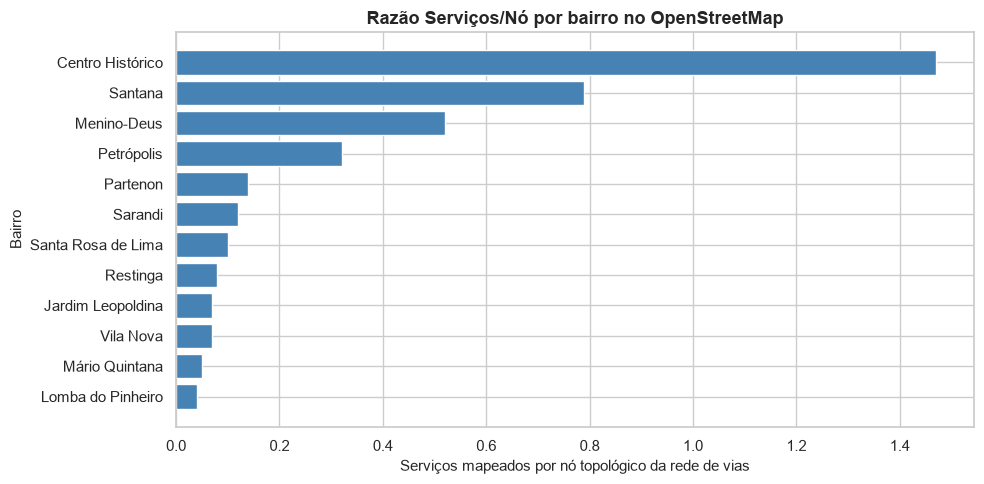

In [17]:
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

df_plot = df_final.sort_values(by='Razão Serviços/Nó', ascending=True)

plt.barh(df_plot['Bairro'], df_plot['Razão Serviços/Nó'], color='steelblue')
plt.title('Razão Serviços/Nó por bairro no OpenStreetMap', fontsize=13, fontweight='bold')
plt.xlabel('Serviços mapeados por nó topológico da rede de vias', fontsize=11)
plt.ylabel('Bairro', fontsize=11)
plt.tight_layout()

plt.savefig('../outputs/grafico_razao_servicos_no.png', dpi=300)
plt.show()

## 13. Limitações e reprodução

**Limitações principais**
- A amostra é intencional e exploratória; não permite generalização estatística para todos os bairros de Porto Alegre.
- As macrozonas são classificações analíticas próprias.
- A unidade bairro agrega heterogeneidades internas.
- Nós e feições de serviços derivam do OpenStreetMap; não constituem observações independentes da infraestrutura ou dos serviços existentes.
- A rede extraída não corresponde exclusivamente a vias motorizadas.
- Os resultados podem ser afetados por limites de bairro, recorte espacial, tags selecionadas, duplicidades semânticas e ausência de registros.
- O indicador não mede oferta real de serviços, completude absoluta, risco, raça/cor, renda ou desempenho de sistemas públicos.
- Os resultados dependem da versão temporal do arquivo PBF.
- Mobilidade, drenagem/hidrografia e infraestrutura viária são descritas conceitualmente no artigo mas não computadas nesta versão do notebook.

**Como reproduzir**
1. Instale as dependências (`requirements.txt` na raiz do repositório).
2. Baixe o arquivo PBF indicado e registre sua versão.
3. Configure a fonte populacional e as geometrias territoriais.
4. Execute as seções na ordem apresentada.
5. Revise a tabela de falhas antes de interpretar os resultados.

**Atribuição**
Dados © contribuidores do OpenStreetMap, sob ODbL. Extrato distribuído pela Geofabrik. Dados populacionais: IBGE/SIDRA. Delimitação municipal: Malha geométrica dos municípios brasileiros (IBGE), catalogada em https://dados.gov.br/dados/conjuntos-dados/malha-geometrica-dos-municipios-brasileiros
